In [2]:
# STEP 1: Simulate 50K+ E-commerce User Event Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Step 1.1 - Define experiment parameters
N_USERS = 50000
CONTROL_SIZE = N_USERS // 2
TREATMENT_SIZE = N_USERS // 2

# Ground truth conversion rates
# Control: existing layout, Treatment: new layout with injected lift
CONTROL_CTR = 0.12        # 12% click-through rate
TREATMENT_CTR = 0.145     # 14.5% click-through rate — 2.5% absolute lift

CONTROL_CVR = 0.035       # 3.5% conversion rate
TREATMENT_CVR = 0.045     # 4.5% conversion rate — 1% absolute lift

print("Experiment Configuration")
print(f"Total users            : {N_USERS:,}")
print(f"Control group size     : {CONTROL_SIZE:,}")
print(f"Treatment group size   : {TREATMENT_SIZE:,}")
print(f"Control CTR            : {CONTROL_CTR*100:.1f}%")
print(f"Treatment CTR          : {TREATMENT_CTR*100:.1f}%")
print(f"Expected CTR lift      : {(TREATMENT_CTR - CONTROL_CTR)*100:.1f}%")
print(f"Control CVR            : {CONTROL_CVR*100:.1f}%")
print(f"Treatment CVR          : {TREATMENT_CVR*100:.1f}%")
print(f"Expected CVR lift      : {(TREATMENT_CVR - CONTROL_CVR)*100:.1f}%")

# Step 1.2 - Simulate user attributes (confounding variables)
user_ids = np.arange(1, N_USERS + 1)
groups = np.array(['control'] * CONTROL_SIZE + ['treatment'] * TREATMENT_SIZE)

# Device type — mobile users convert lower than desktop historically
devices = np.random.choice(
    ['mobile', 'desktop', 'tablet'],
    size=N_USERS,
    p=[0.55, 0.35, 0.10]
)

# Age group — different segments respond differently to UI changes
age_groups = np.random.choice(
    ['18-24', '25-34', '35-44', '45-54', '55+'],
    size=N_USERS,
    p=[0.20, 0.30, 0.25, 0.15, 0.10]
)

# Geography
geography = np.random.choice(
    ['North', 'South', 'East', 'West'],
    size=N_USERS,
    p=[0.25, 0.25, 0.25, 0.25]
)

# Step 1.3 - Simulate click-through outcomes
# Bernoulli trial — 1 = clicked, 0 = did not click
clicked = np.where(
    groups == 'control',
    np.random.binomial(1, CONTROL_CTR, N_USERS),
    np.random.binomial(1, TREATMENT_CTR, N_USERS)
)

# Step 1.4 - Simulate conversion outcomes
# User can only convert if they clicked first
converted = np.where(
    groups == 'control',
    np.random.binomial(1, CONTROL_CVR, N_USERS),
    np.random.binomial(1, TREATMENT_CVR, N_USERS)
)

# Enforce funnel logic — conversion requires click
converted = np.where(clicked == 1, converted, 0)

# Step 1.5 - Simulate session duration in seconds
# Treatment group sessions are slightly longer due to better UI engagement
session_duration = np.where(
    groups == 'control',
    np.random.normal(loc=180, scale=60, size=N_USERS).clip(10, 600),
    np.random.normal(loc=210, scale=65, size=N_USERS).clip(10, 600)
)

# Step 1.6 - Simulate timestamps over a 30-day experiment window
start_date = pd.Timestamp('2024-01-01')
end_date = pd.Timestamp('2024-01-31')
timestamps = pd.to_datetime(
    np.random.uniform(start_date.value, end_date.value, N_USERS)
)

# Step 1.7 - Assemble into structured DataFrame
df = pd.DataFrame({
    'user_id'          : user_ids,
    'group'            : groups,
    'device'           : devices,
    'age_group'        : age_groups,
    'geography'        : geography,
    'clicked'          : clicked,
    'converted'        : converted,
    'session_duration' : session_duration.round(1),
    'timestamp'        : timestamps
})

df = df.sort_values('timestamp').reset_index(drop=True)

# Step 1.8 - Validate dataset
print(f"\nDataset Shape: {df.shape}")
print(f"\nSchema")
print(df.dtypes)
print(f"\nSample Records (first 5)")
print(df.head())

# Step 1.9 - Group-level summary statistics
print(f"\nGroup Level Summary")
summary = df.groupby('group').agg(
    total_users      = ('user_id', 'count'),
    total_clicks     = ('clicked', 'sum'),
    total_conversions= ('converted', 'sum'),
    ctr              = ('clicked', 'mean'),
    cvr              = ('converted', 'mean'),
    avg_session_dur  = ('session_duration', 'mean')
).round(4)
print(summary)

Experiment Configuration
Total users            : 50,000
Control group size     : 25,000
Treatment group size   : 25,000
Control CTR            : 12.0%
Treatment CTR          : 14.5%
Expected CTR lift      : 2.5%
Control CVR            : 3.5%
Treatment CVR          : 4.5%
Expected CVR lift      : 1.0%

Dataset Shape: (50000, 9)

Schema
user_id                      int64
group                       object
device                      object
age_group                   object
geography                   object
clicked                      int64
converted                    int64
session_duration           float64
timestamp           datetime64[ns]
dtype: object

Sample Records (first 5)
   user_id      group   device age_group geography  clicked  converted  \
0    24252    control   tablet     25-34      East        0          0   
1    36148  treatment   mobile     25-34     North        0          0   
2    10147    control  desktop     45-54     North        0          0   
3    27635 

FREQUENTIST A/B TESTING

Test 1: Chi-Square Test on CTR
Null Hypothesis H0: CTR is equal across control and treatment
Alt Hypothesis  H1: CTR differs significantly between groups

Contingency Table (CTR):
clicked        0     1
group                 
control    21976  3024
treatment  21272  3728

Chi-Square Statistic : 84.6218
Degrees of Freedom   : 1
p-value              : 0.000000
Result               : SIGNIFICANT — Reject H0

Control CTR          : 0.1210 (12.10%)
Treatment CTR        : 0.1491 (14.91%)
Relative CTR Lift    : 23.28%

Test 2: Chi-Square Test on CVR
Null Hypothesis H0: CVR is equal across control and treatment
Alt Hypothesis  H1: CVR differs significantly between groups

Contingency Table (CVR):
converted      0    1
group                
control    24898  102
treatment  24830  170

Chi-Square Statistic : 16.5939
Degrees of Freedom   : 1
p-value              : 0.000046
Result               : SIGNIFICANT — Reject H0

Control CVR          : 0.0041 (0.41%)
Treatment CVR 

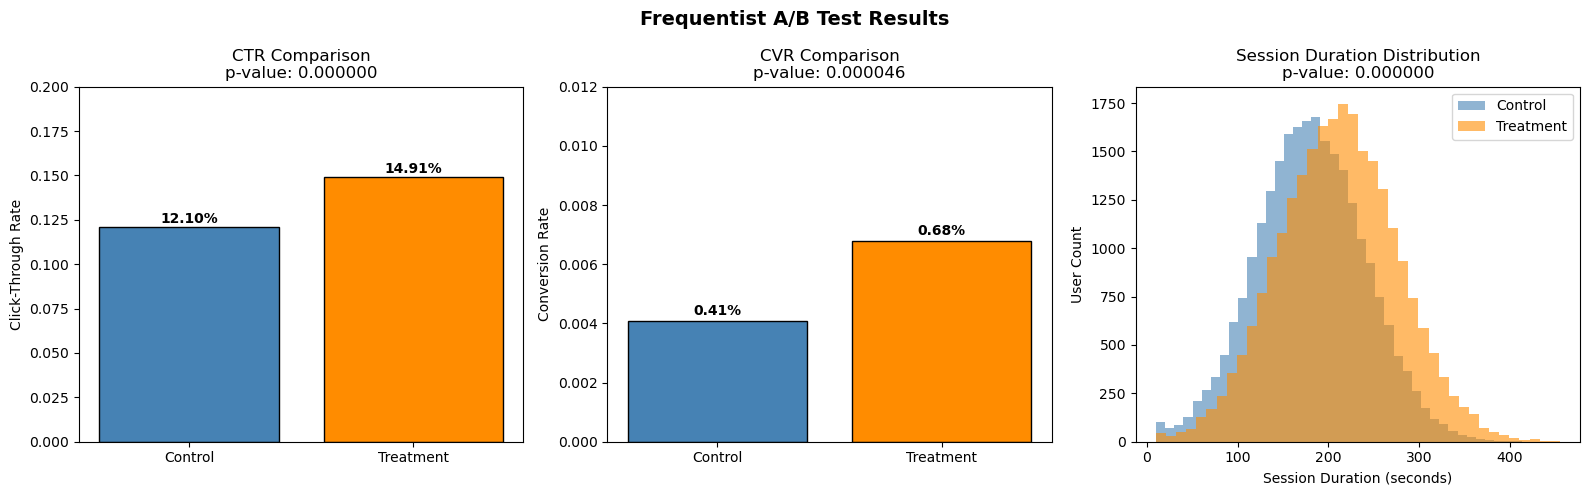


Plot saved as frequentist_ab_test.png


In [3]:
# STEP 2: Frequentist A/B Testing — Chi-Square and t-test

from scipy.stats import chi2_contingency, ttest_ind

print("FREQUENTIST A/B TESTING")

# Step 2.1 - Separate control and treatment groups
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# Step 2.2 - Chi-Square test on Click-Through Rate (CTR)
print("\nTest 1: Chi-Square Test on CTR")
print("Null Hypothesis H0: CTR is equal across control and treatment")
print("Alt Hypothesis  H1: CTR differs significantly between groups\n")

# Contingency table — rows: group, cols: clicked/not clicked
ctr_contingency = pd.crosstab(df['group'], df['clicked'])
print("Contingency Table (CTR):")
print(ctr_contingency)

chi2_ctr, p_ctr, dof_ctr, expected_ctr = chi2_contingency(ctr_contingency)

print(f"\nChi-Square Statistic : {chi2_ctr:.4f}")
print(f"Degrees of Freedom   : {dof_ctr}")
print(f"p-value              : {p_ctr:.6f}")
print(f"Result               : {'SIGNIFICANT — Reject H0' if p_ctr < 0.05 else 'NOT SIGNIFICANT — Fail to reject H0'}")

control_ctr = control['clicked'].mean()
treatment_ctr = treatment['clicked'].mean()
ctr_lift = ((treatment_ctr - control_ctr) / control_ctr) * 100
print(f"\nControl CTR          : {control_ctr:.4f} ({control_ctr*100:.2f}%)")
print(f"Treatment CTR        : {treatment_ctr:.4f} ({treatment_ctr*100:.2f}%)")
print(f"Relative CTR Lift    : {ctr_lift:.2f}%")

# Step 2.3 - Chi-Square test on Conversion Rate (CVR)
print("\nTest 2: Chi-Square Test on CVR")
print("Null Hypothesis H0: CVR is equal across control and treatment")
print("Alt Hypothesis  H1: CVR differs significantly between groups\n")

cvr_contingency = pd.crosstab(df['group'], df['converted'])
print("Contingency Table (CVR):")
print(cvr_contingency)

chi2_cvr, p_cvr, dof_cvr, expected_cvr = chi2_contingency(cvr_contingency)

print(f"\nChi-Square Statistic : {chi2_cvr:.4f}")
print(f"Degrees of Freedom   : {dof_cvr}")
print(f"p-value              : {p_cvr:.6f}")
print(f"Result               : {'SIGNIFICANT — Reject H0' if p_cvr < 0.05 else 'NOT SIGNIFICANT — Fail to reject H0'}")

control_cvr = control['converted'].mean()
treatment_cvr = treatment['converted'].mean()
cvr_lift = ((treatment_cvr - control_cvr) / control_cvr) * 100
print(f"\nControl CVR          : {control_cvr:.4f} ({control_cvr*100:.2f}%)")
print(f"Treatment CVR        : {treatment_cvr:.4f} ({treatment_cvr*100:.2f}%)")
print(f"Relative CVR Lift    : {cvr_lift:.2f}%")

# Step 2.4 - Two-sample t-test on Session Duration
print("\nTest 3: Two-Sample t-test on Session Duration")
print("Null Hypothesis H0: Mean session duration is equal across groups")
print("Alt Hypothesis  H1: Mean session duration differs between groups\n")

t_stat, p_session = ttest_ind(
    control['session_duration'],
    treatment['session_duration'],
    equal_var=False   # Welch's t-test — does not assume equal variance
)

print(f"t-statistic          : {t_stat:.4f}")
print(f"p-value              : {p_session:.6f}")
print(f"Result               : {'SIGNIFICANT — Reject H0' if p_session < 0.05 else 'NOT SIGNIFICANT — Fail to reject H0'}")
print(f"\nControl avg session  : {control['session_duration'].mean():.2f}s")
print(f"Treatment avg session: {treatment['session_duration'].mean():.2f}s")

# Step 2.5 - Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CTR comparison
axes[0].bar(['Control', 'Treatment'],
            [control_ctr, treatment_ctr],
            color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title(f'CTR Comparison\np-value: {p_ctr:.6f}')
axes[0].set_ylabel('Click-Through Rate')
axes[0].set_ylim(0, 0.20)
for i, v in enumerate([control_ctr, treatment_ctr]):
    axes[0].text(i, v + 0.002, f'{v*100:.2f}%', ha='center', fontweight='bold')

# CVR comparison
axes[1].bar(['Control', 'Treatment'],
            [control_cvr, treatment_cvr],
            color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title(f'CVR Comparison\np-value: {p_cvr:.6f}')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_ylim(0, 0.012)
for i, v in enumerate([control_cvr, treatment_cvr]):
    axes[1].text(i, v + 0.0002, f'{v*100:.2f}%', ha='center', fontweight='bold')

# Session duration distribution
axes[2].hist(control['session_duration'], bins=40, alpha=0.6,
             color='steelblue', label='Control', edgecolor='none')
axes[2].hist(treatment['session_duration'], bins=40, alpha=0.6,
             color='darkorange', label='Treatment', edgecolor='none')
axes[2].set_title(f'Session Duration Distribution\np-value: {p_session:.6f}')
axes[2].set_xlabel('Session Duration (seconds)')
axes[2].set_ylabel('User Count')
axes[2].legend()

plt.suptitle('Frequentist A/B Test Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('frequentist_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as frequentist_ab_test.png")

BAYESIAN A/B TESTING

Observed CTR Data
Control   — Clicks: 3,024 | No Clicks: 21,976
Treatment — Clicks: 3,728 | No Clicks: 21,272

CTR Posterior Parameters
Control   posterior: Beta(3025, 21977)
Treatment posterior: Beta(3729, 21273)

Bayesian CTR Results
P(Treatment CTR > Control CTR) : 1.0000 (100.00%)
Expected absolute lift         : 0.0282 (2.82%)

Observed CVR Data
Control   — Conversions: 102 | No Conversions: 24,898
Treatment — Conversions: 170 | No Conversions: 24,830

Bayesian CVR Results
P(Treatment CVR > Control CVR) : 1.0000 (100.00%)
Expected absolute lift         : 0.0027 (0.27%)

95% Credible Intervals
CTR lift credible interval : [0.0222, 0.0341]
CVR lift credible interval : [0.0014, 0.0040]


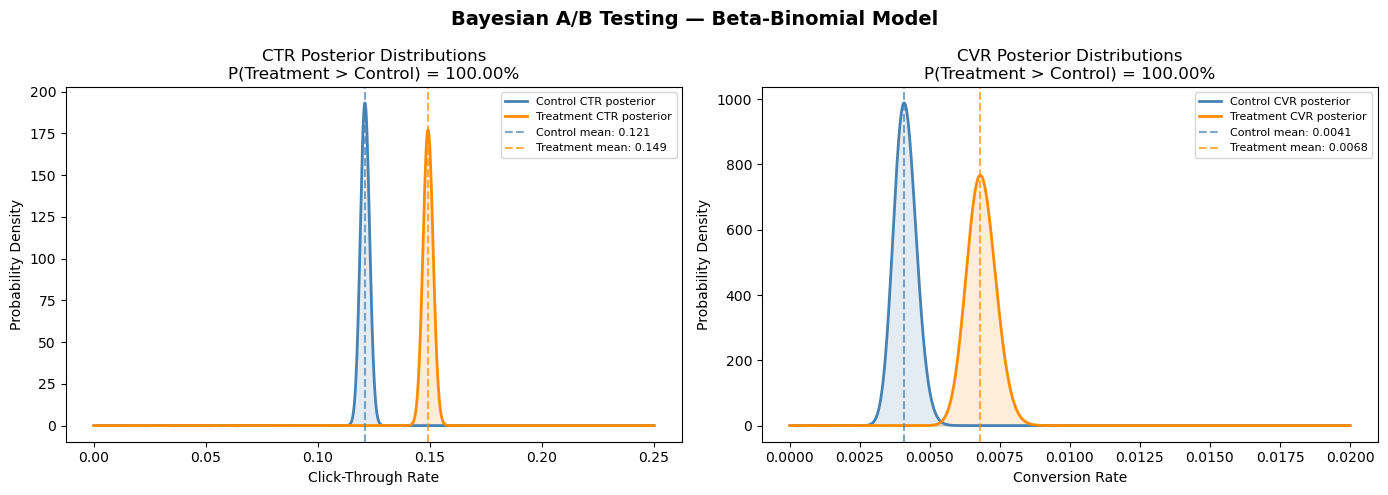


Plot saved as bayesian_ab_test.png


In [5]:
# STEP 3: Bayesian A/B Testing — Beta-Binomial Model

print("BAYESIAN A/B TESTING")

# Step 3.1 - Extract observed counts for CTR
clicks_control     = control['clicked'].sum()
no_clicks_control  = len(control) - clicks_control
clicks_treatment   = treatment['clicked'].sum()
no_clicks_treatment = len(treatment) - clicks_treatment

print(f"\nObserved CTR Data")
print(f"Control   — Clicks: {clicks_control:,} | No Clicks: {no_clicks_control:,}")
print(f"Treatment — Clicks: {clicks_treatment:,} | No Clicks: {no_clicks_treatment:,}")

# Step 3.2 - Define Beta posterior distributions for CTR
# Prior: Beta(1,1) — uniform, weakly informative
# Posterior: Beta(1 + successes, 1 + failures) — Bayesian updating
alpha_control_ctr   = 1 + clicks_control
beta_control_ctr    = 1 + no_clicks_control
alpha_treatment_ctr = 1 + clicks_treatment
beta_treatment_ctr  = 1 + no_clicks_treatment

print(f"\nCTR Posterior Parameters")
print(f"Control   posterior: Beta({alpha_control_ctr}, {beta_control_ctr})")
print(f"Treatment posterior: Beta({alpha_treatment_ctr}, {beta_treatment_ctr})")

# Step 3.3 - Monte Carlo sampling — draw 100K samples from posteriors
N_SAMPLES = 100000
samples_control_ctr   = np.random.beta(alpha_control_ctr, beta_control_ctr, N_SAMPLES)
samples_treatment_ctr = np.random.beta(alpha_treatment_ctr, beta_treatment_ctr, N_SAMPLES)

# Step 3.4 - Compute Bayesian probability treatment > control
prob_treatment_better_ctr = (samples_treatment_ctr > samples_control_ctr).mean()
expected_lift_ctr = (samples_treatment_ctr - samples_control_ctr).mean()

print(f"\nBayesian CTR Results")
print(f"P(Treatment CTR > Control CTR) : {prob_treatment_better_ctr:.4f} ({prob_treatment_better_ctr*100:.2f}%)")
print(f"Expected absolute lift         : {expected_lift_ctr:.4f} ({expected_lift_ctr*100:.2f}%)")

# Step 3.5 - Repeat for CVR
conversions_control     = control['converted'].sum()
no_conversions_control  = len(control) - conversions_control
conversions_treatment   = treatment['converted'].sum()
no_conversions_treatment = len(treatment) - conversions_treatment

print(f"\nObserved CVR Data")
print(f"Control   — Conversions: {conversions_control:,} | No Conversions: {no_conversions_control:,}")
print(f"Treatment — Conversions: {conversions_treatment:,} | No Conversions: {no_conversions_treatment:,}")

alpha_control_cvr   = 1 + conversions_control
beta_control_cvr    = 1 + no_conversions_control
alpha_treatment_cvr = 1 + conversions_treatment
beta_treatment_cvr  = 1 + no_conversions_treatment

samples_control_cvr   = np.random.beta(alpha_control_cvr, beta_control_cvr, N_SAMPLES)
samples_treatment_cvr = np.random.beta(alpha_treatment_cvr, beta_treatment_cvr, N_SAMPLES)

prob_treatment_better_cvr = (samples_treatment_cvr > samples_control_cvr).mean()
expected_lift_cvr = (samples_treatment_cvr - samples_control_cvr).mean()

print(f"\nBayesian CVR Results")
print(f"P(Treatment CVR > Control CVR) : {prob_treatment_better_cvr:.4f} ({prob_treatment_better_cvr*100:.2f}%)")
print(f"Expected absolute lift         : {expected_lift_cvr:.4f} ({expected_lift_cvr*100:.2f}%)")

# Step 3.6 - Compute credible intervals (Bayesian equivalent of confidence intervals)
ctr_credible_low  = np.percentile(samples_treatment_ctr - samples_control_ctr, 2.5)
ctr_credible_high = np.percentile(samples_treatment_ctr - samples_control_ctr, 97.5)
cvr_credible_low  = np.percentile(samples_treatment_cvr - samples_control_cvr, 2.5)
cvr_credible_high = np.percentile(samples_treatment_cvr - samples_control_cvr, 97.5)

print(f"\n95% Credible Intervals")
print(f"CTR lift credible interval : [{ctr_credible_low:.4f}, {ctr_credible_high:.4f}]")
print(f"CVR lift credible interval : [{cvr_credible_low:.4f}, {cvr_credible_high:.4f}]")

# Step 3.7 - Visualize posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 0.25, 1000)

# CTR posteriors
from scipy.stats import beta as beta_dist

axes[0].plot(x, beta_dist.pdf(x, alpha_control_ctr, beta_control_ctr),
             color='steelblue', linewidth=2, label=f'Control CTR posterior')
axes[0].plot(x, beta_dist.pdf(x, alpha_treatment_ctr, beta_treatment_ctr),
             color='darkorange', linewidth=2, label=f'Treatment CTR posterior')
axes[0].axvline(x=clicks_control/len(control), color='steelblue',
                linestyle='--', alpha=0.7, label=f'Control mean: {clicks_control/len(control):.3f}')
axes[0].axvline(x=clicks_treatment/len(treatment), color='darkorange',
                linestyle='--', alpha=0.7, label=f'Treatment mean: {clicks_treatment/len(treatment):.3f}')
axes[0].fill_between(x,
    beta_dist.pdf(x, alpha_control_ctr, beta_control_ctr),
    alpha=0.15, color='steelblue')
axes[0].fill_between(x,
    beta_dist.pdf(x, alpha_treatment_ctr, beta_treatment_ctr),
    alpha=0.15, color='darkorange')
axes[0].set_title(f'CTR Posterior Distributions\nP(Treatment > Control) = {prob_treatment_better_ctr*100:.2f}%')
axes[0].set_xlabel('Click-Through Rate')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8)

# CVR posteriors
x2 = np.linspace(0, 0.02, 1000)
axes[1].plot(x2, beta_dist.pdf(x2, alpha_control_cvr, beta_control_cvr),
             color='steelblue', linewidth=2, label=f'Control CVR posterior')
axes[1].plot(x2, beta_dist.pdf(x2, alpha_treatment_cvr, beta_treatment_cvr),
             color='darkorange', linewidth=2, label=f'Treatment CVR posterior')
axes[1].axvline(x=conversions_control/len(control), color='steelblue',
                linestyle='--', alpha=0.7, label=f'Control mean: {conversions_control/len(control):.4f}')
axes[1].axvline(x=conversions_treatment/len(treatment), color='darkorange',
                linestyle='--', alpha=0.7, label=f'Treatment mean: {conversions_treatment/len(treatment):.4f}')
axes[1].fill_between(x2,
    beta_dist.pdf(x2, alpha_control_cvr, beta_control_cvr),
    alpha=0.15, color='steelblue')
axes[1].fill_between(x2,
    beta_dist.pdf(x2, alpha_treatment_cvr, beta_treatment_cvr),
    alpha=0.15, color='darkorange')
axes[1].set_title(f'CVR Posterior Distributions\nP(Treatment > Control) = {prob_treatment_better_cvr*100:.2f}%')
axes[1].set_xlabel('Conversion Rate')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8)

plt.suptitle('Bayesian A/B Testing — Beta-Binomial Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bayesian_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as bayesian_ab_test.png")